In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
# UPDATED WORKING URL:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/historical_automobile_sales.csv"
df = pd.read_csv(URL)

# Verify loaded dataset
df.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1/31/1980,1980,Jan,1,108.24,0.50,27483.571,1558,7,60.223,0.010000,5.4,456.0,Supperminicar,Georgia
1,2/29/1980,1980,Feb,1,98.75,0.75,24308.678,3048,4,45.986,-0.309594,4.8,555.9,Supperminicar,New York
2,3/31/1980,1980,Mar,1,107.48,0.20,28238.443,3137,3,35.141,-0.308614,3.4,620.0,Mediumfamilycar,New York
3,4/30/1980,1980,Apr,1,115.01,1.00,32615.149,1653,7,45.673,0.230596,4.2,702.8,Supperminicar,Illinois
4,5/31/1980,1980,May,1,98.72,0.20,23829.233,1319,4,52.997,0.138197,5.3,770.4,Smallfamiliycar,California


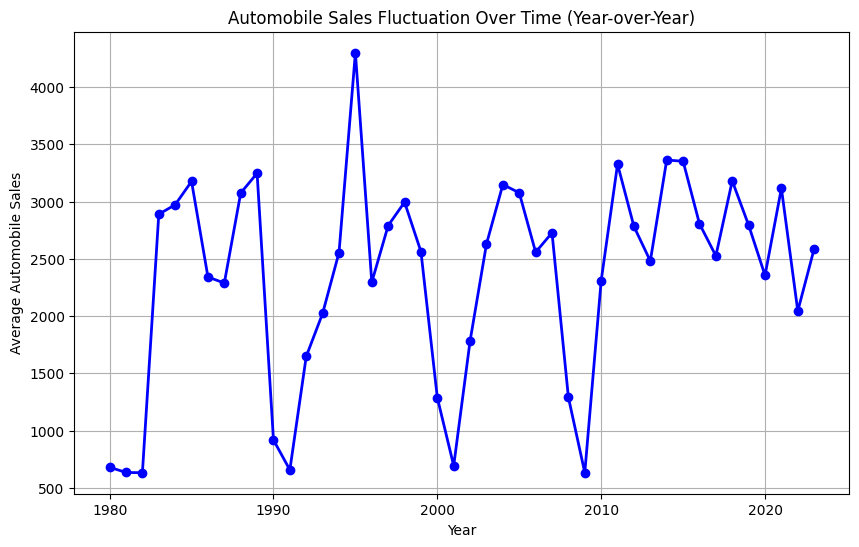

In [5]:
plt.figure(figsize=(10, 6))
df_line = df.groupby('Year')['Automobile_Sales'].mean().reset_index()
plt.plot(df_line['Year'], df_line['Automobile_Sales'], marker='o', color='b', linewidth=2)
plt.title('Automobile Sales Fluctuation Over Time (Year-over-Year)')
plt.xlabel('Year')
plt.ylabel('Average Automobile Sales')
plt.grid(True)
plt.show()

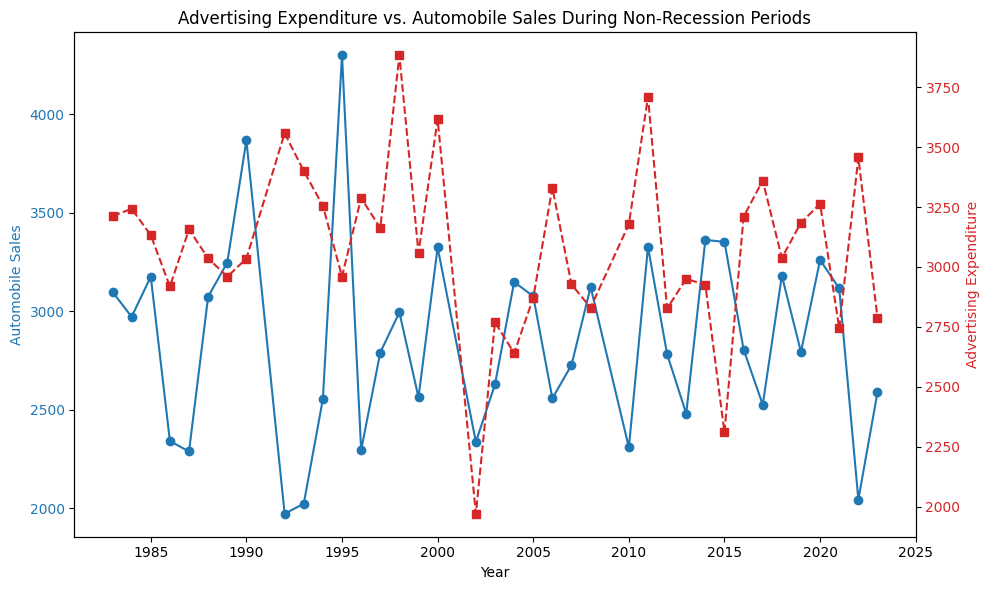

In [6]:
df_non_rec = df[df['Recession'] == 0]

fig, ax1 = plt.subplots(figsize=(10, 6))

df_ad_sales = df_non_rec.groupby('Year')[['Advertising_Expenditure', 'Automobile_Sales']].mean().reset_index()

ax1.set_xlabel('Year')
ax1.set_ylabel('Automobile Sales', color='tab:blue')
ax1.plot(df_ad_sales['Year'], df_ad_sales['Automobile_Sales'], color='tab:blue', marker='o', label='Automobile Sales')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Advertising Expenditure', color='tab:red')
ax2.plot(df_ad_sales['Year'], df_ad_sales['Advertising_Expenditure'], color='tab:red', linestyle='--', marker='s', label='Ad Spend')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Advertising Expenditure vs. Automobile Sales During Non-Recession Periods')
fig.tight_layout()
plt.show()

C:\Users\intel\AppData\Local\Temp\ipykernel_12920\2350446253.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Vehicle_Type', y='Automobile_Sales', hue='Recession', ci=None)


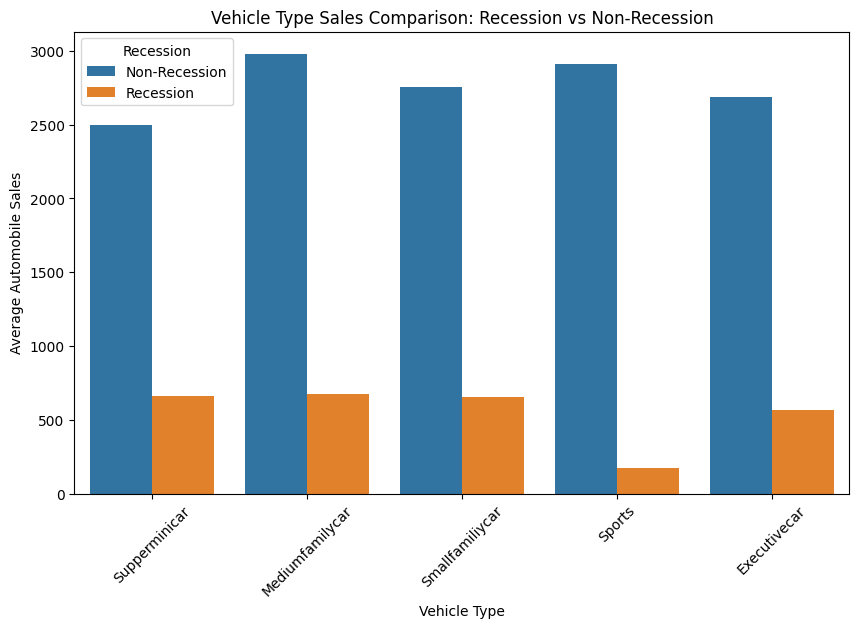

In [7]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Vehicle_Type', y='Automobile_Sales', hue='Recession', ci=None)
plt.title('Vehicle Type Sales Comparison: Recession vs Non-Recession')
plt.xlabel('Vehicle Type')
plt.ylabel('Average Automobile Sales')
plt.legend(title='Recession', labels=['Non-Recession', 'Recession'])
plt.xticks(rotation=45)
plt.show()

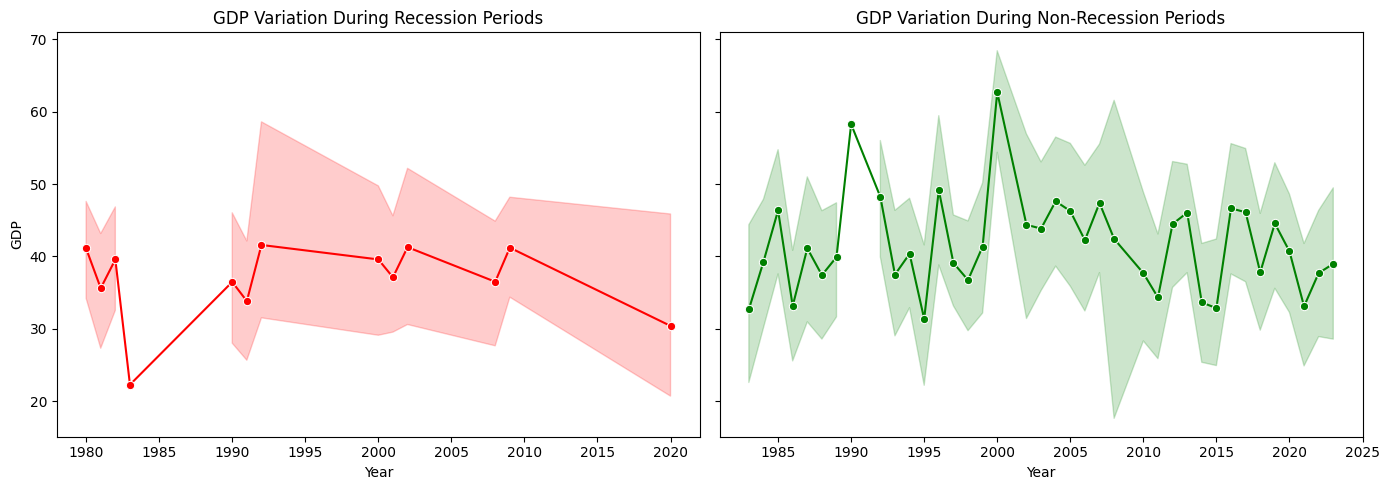

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Plot 1: Recession Period GDP
df_rec = df[df['Recession'] == 1]
sns.lineplot(data=df_rec, x='Year', y='GDP', ax=axes[0], color='red', marker='o')
axes[0].set_title('GDP Variation During Recession Periods')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('GDP')

# Plot 2: Non-Recession Period GDP
sns.lineplot(data=df_non_rec, x='Year', y='GDP', ax=axes[1], color='green', marker='o')
axes[1].set_title('GDP Variation During Non-Recession Periods')
axes[1].set_xlabel('Year')

plt.tight_layout()
plt.show()

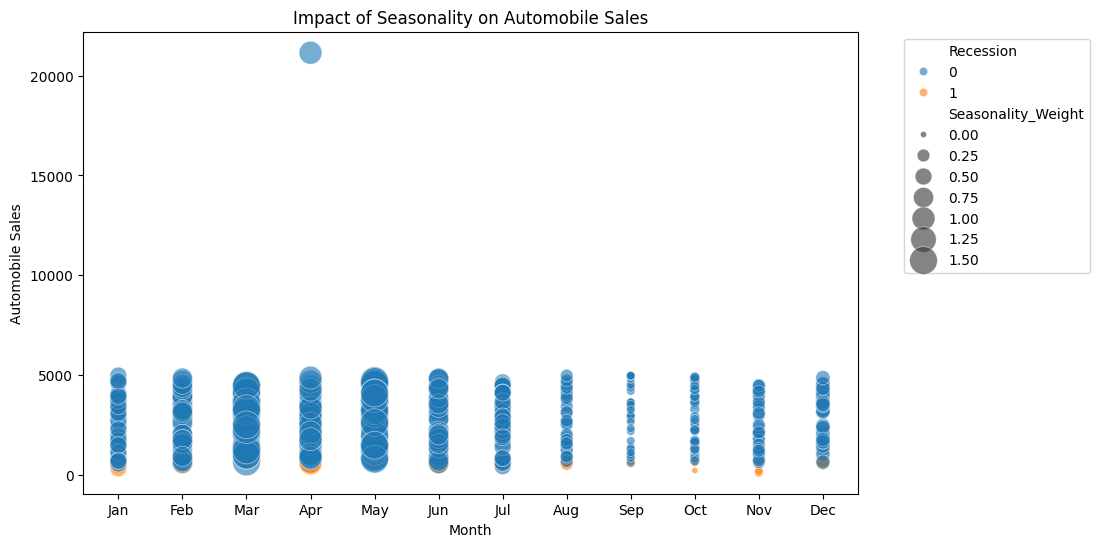

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='Month', 
    y='Automobile_Sales', 
    size='Seasonality_Weight', 
    hue='Recession', 
    sizes=(20, 400), 
    alpha=0.6
)
plt.title('Impact of Seasonality on Automobile Sales')
plt.xlabel('Month')
plt.ylabel('Automobile Sales')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

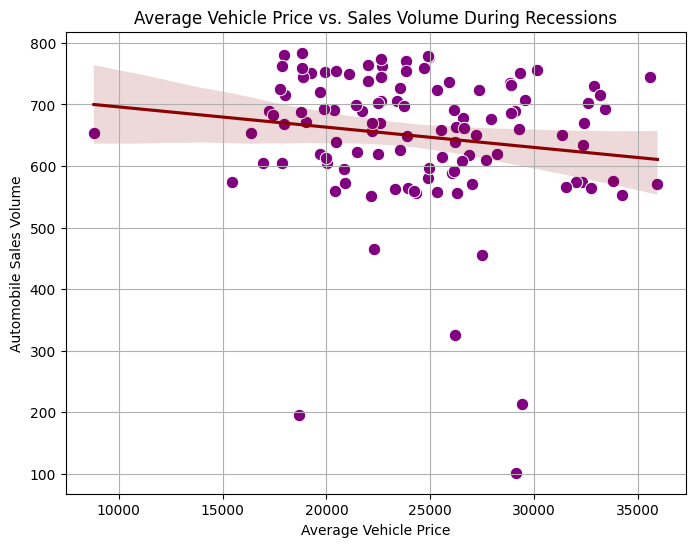

In [10]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_rec, x='Price', y='Automobile_Sales', color='purple', s=80)
sns.regplot(data=df_rec, x='Price', y='Automobile_Sales', scatter=False, color='darkred')
plt.title('Average Vehicle Price vs. Sales Volume During Recessions')
plt.xlabel('Average Vehicle Price')
plt.ylabel('Automobile Sales Volume')
plt.grid(True)
plt.show()

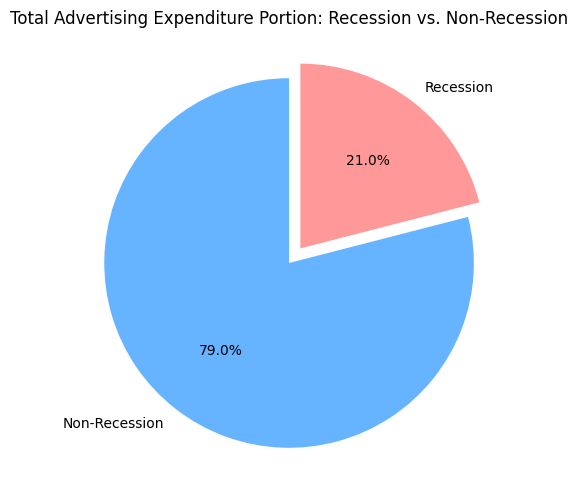

In [11]:
plt.figure(figsize=(6, 6))
ad_total = df.groupby('Recession')['Advertising_Expenditure'].sum()
plt.pie(
    ad_total, 
    labels=['Non-Recession', 'Recession'], 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['#66b3ff', '#ff9999'], 
    explode=(0, 0.1)
)
plt.title('Total Advertising Expenditure Portion: Recession vs. Non-Recession')
plt.show()

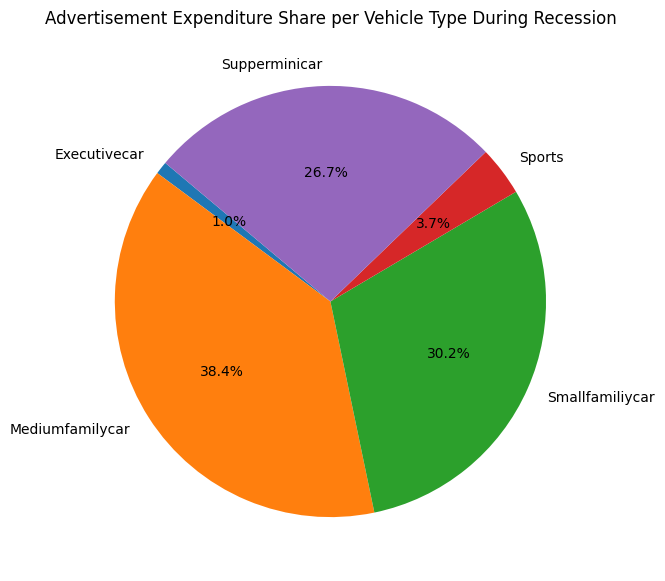

In [12]:
plt.figure(figsize=(7, 7))
ad_rec_veh = df_rec.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()
plt.pie(
    ad_rec_veh, 
    labels=ad_rec_veh.index, 
    autopct='%1.1f%%', 
    startangle=140
)
plt.title('Advertisement Expenditure Share per Vehicle Type During Recession')
plt.show()

C:\Users\intel\AppData\Local\Temp\ipykernel_12920\137504193.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df_rec, x='unemployment_rate', y='Automobile_Sales', hue='Vehicle_Type', ci=None, marker='o')


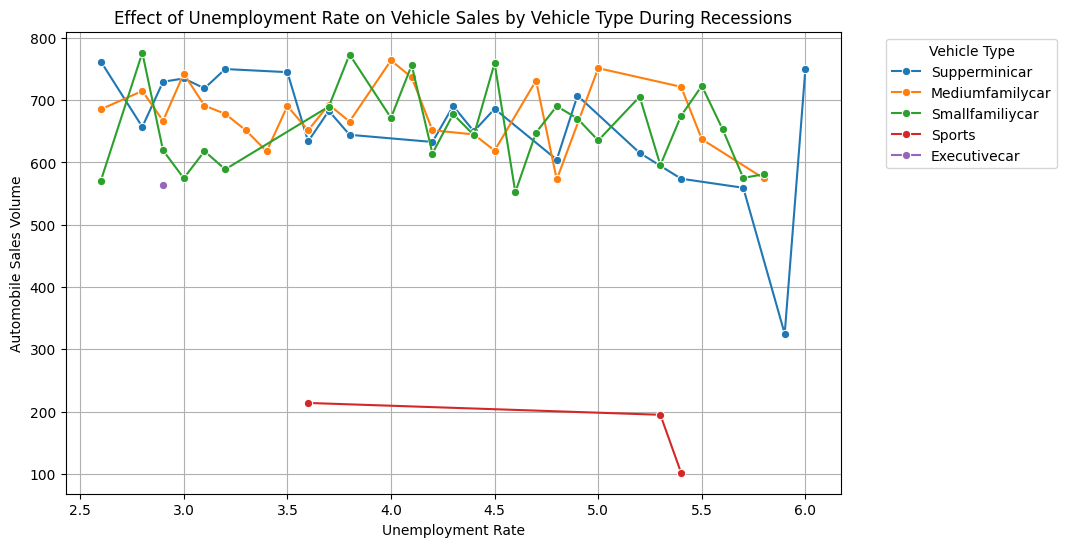

In [13]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_rec, x='unemployment_rate', y='Automobile_Sales', hue='Vehicle_Type', ci=None, marker='o')
plt.title('Effect of Unemployment Rate on Vehicle Sales by Vehicle Type During Recessions')
plt.xlabel('Unemployment Rate')
plt.ylabel('Automobile Sales Volume')
plt.legend(title='Vehicle Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()